In [1]:
import sys
import os
import random
import zipfile
import requests
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)

Project: C:\Documents\GeoSigLIP


In [4]:
from pathlib import Path
import requests

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

DCID_URL = "https://huggingface.co/datasets/168sir/drill-core-image-dataset/resolve/main/DCID.zip"

zip_path = RAW_DIR / "DCID.zip"

print("Downloading to:", zip_path)

response = requests.get(
    DCID_URL,
    stream=True,
    timeout=60
)

response.raise_for_status()

total_size = int(response.headers.get("content-length", 0))
downloaded = 0

with open(zip_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total_size:
                print(
                    f"\rDownloaded: {downloaded / total_size * 100:.1f}%",
                    end=""
                )

print("\nDownload complete.")
print("Size:", zip_path.stat().st_size / 1024**3, "GB")

Downloaded: 100.0%
Download complete.
Size: 3.5575834792107344 GB


In [5]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

print("Total files:", len(names))

for name in names[:30]:
    print(name)

Total files: 98182
DCID/
DCID/build_dcid_dataset.py
DCID/DCID-512-35/
DCID/DCID-512-35/test/
DCID/DCID-512-35/test/1.Red sandstone/
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_1.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_10.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_100.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_101.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_102.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_103.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_104.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_105.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_106.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_107.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_108.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_109.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_11.jpg
DCID/DCID-512-35/test/1.Red sandstone/1.Red sandstone_110.jpg
DCID

In [11]:
from pathlib import Path

DCID_ROOT = RAW_DIR / "DCID" / "DCID-512-35"

print("Dataset exists:", DCID_ROOT.exists())
print("Path:", DCID_ROOT)

Dataset exists: False
Path: C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-35


In [13]:
from pathlib import Path

RAW_DIR = Path.cwd().parent / "data" / "raw"

dcid_dir = RAW_DIR / "DCID"

print("DCID directory:", dcid_dir)
print("Exists:", dcid_dir.exists())

print("\nDIRECTORY STRUCTURE:")
for path in sorted(dcid_dir.rglob("*")):
    relative = path.relative_to(dcid_dir)

    # Show only directories and the first few files
    if path.is_dir():
        print("[DIR] ", relative)

DCID directory: C:\Documents\GeoSigLIP\data\raw\DCID
Exists: True

DIRECTORY STRUCTURE:
[DIR]  DCID-512-7
[DIR]  DCID-512-7\test
[DIR]  DCID-512-7\test\1.Red sandstone
[DIR]  DCID-512-7\test\2.Light sandstone
[DIR]  DCID-512-7\test\3.Gray siltstone
[DIR]  DCID-512-7\test\4.Mudstone
[DIR]  DCID-512-7\test\5.Granite
[DIR]  DCID-512-7\test\6.Basalt
[DIR]  DCID-512-7\test\7.Marble
[DIR]  DCID-512-7\train
[DIR]  DCID-512-7\train\1.Red sandstone
[DIR]  DCID-512-7\train\2.Light sandstone
[DIR]  DCID-512-7\train\3.Gray siltstone
[DIR]  DCID-512-7\train\4.Mudstone
[DIR]  DCID-512-7\train\5.Granite
[DIR]  DCID-512-7\train\6.Basalt
[DIR]  DCID-512-7\train\7.Marble


In [14]:
from pathlib import Path
import pandas as pd
import random

DCID_ROOT = RAW_DIR / "DCID" / "DCID-512-7"

train_root = DCID_ROOT / "train"
test_root = DCID_ROOT / "test"

TARGET_CLASSES = [
    "1.Red sandstone",
    "2.Light sandstone",
    "3.Gray siltstone",
    "4.Mudstone",
    "5.Granite",
    "6.Basalt",
    "7.Marble"
]

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print("Train:", train_root)
print("Test:", test_root)

print("\nImages per training class:")

for class_name in TARGET_CLASSES:
    class_dir = train_root / class_name
    
    images = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]
    
    print(f"{class_name}: {len(images)}")

Train: C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-7\train
Test: C:\Documents\GeoSigLIP\data\raw\DCID\DCID-512-7\test

Images per training class:
1.Red sandstone: 4000
2.Light sandstone: 4000
3.Gray siltstone: 4000
4.Mudstone: 4000
5.Granite: 4000
6.Basalt: 4000
7.Marble: 4000


In [15]:
SAMPLES_TRAIN_PER_CLASS = 500
SAMPLES_TEST_PER_CLASS = 250

random.seed(SEED)

train_records = []
test_records = []

for class_name in TARGET_CLASSES:

    # Training images
    train_images = [
        p for p in (train_root / class_name).iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    selected_train = random.sample(
        train_images,
        SAMPLES_TRAIN_PER_CLASS
    )

    for path in selected_train:
        train_records.append({
            "image_path": str(path),
            "label": class_name.split(".", 1)[1]
        })

    # Official test images — kept completely separate
    test_images = [
        p for p in (test_root / class_name).iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    selected_test = random.sample(
        test_images,
        SAMPLES_TEST_PER_CLASS
    )

    for path in selected_test:
        test_records.append({
            "image_path": str(path),
            "label": class_name.split(".", 1)[1]
        })

train_df = pd.DataFrame(train_records)
test_df = pd.DataFrame(test_records)

print("Training images:", len(train_df))
print("Test images:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Training images: 3500
Test images: 1750

Training distribution:
label
Red sandstone      500
Light sandstone    500
Gray siltstone     500
Mudstone           500
Granite            500
Basalt             500
Marble             500
Name: count, dtype: int64

Test distribution:
label
Red sandstone      250
Light sandstone    250
Gray siltstone     250
Mudstone           250
Granite            250
Basalt             250
Marble             250
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.30,
    stratify=train_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["label"].value_counts().sort_index())

Train: 2450
Validation: 1050
Test: 1750

Train distribution:
label
Basalt             350
Granite            350
Gray siltstone     350
Light sandstone    350
Marble             350
Mudstone           350
Red sandstone      350
Name: count, dtype: int64

Validation distribution:
label
Basalt             150
Granite            150
Gray siltstone     150
Light sandstone    150
Marble             150
Mudstone           150
Red sandstone      150
Name: count, dtype: int64

Test distribution:
label
Basalt             250
Granite            250
Gray siltstone     250
Light sandstone    250
Marble             250
Mudstone           250
Red sandstone      250
Name: count, dtype: int64


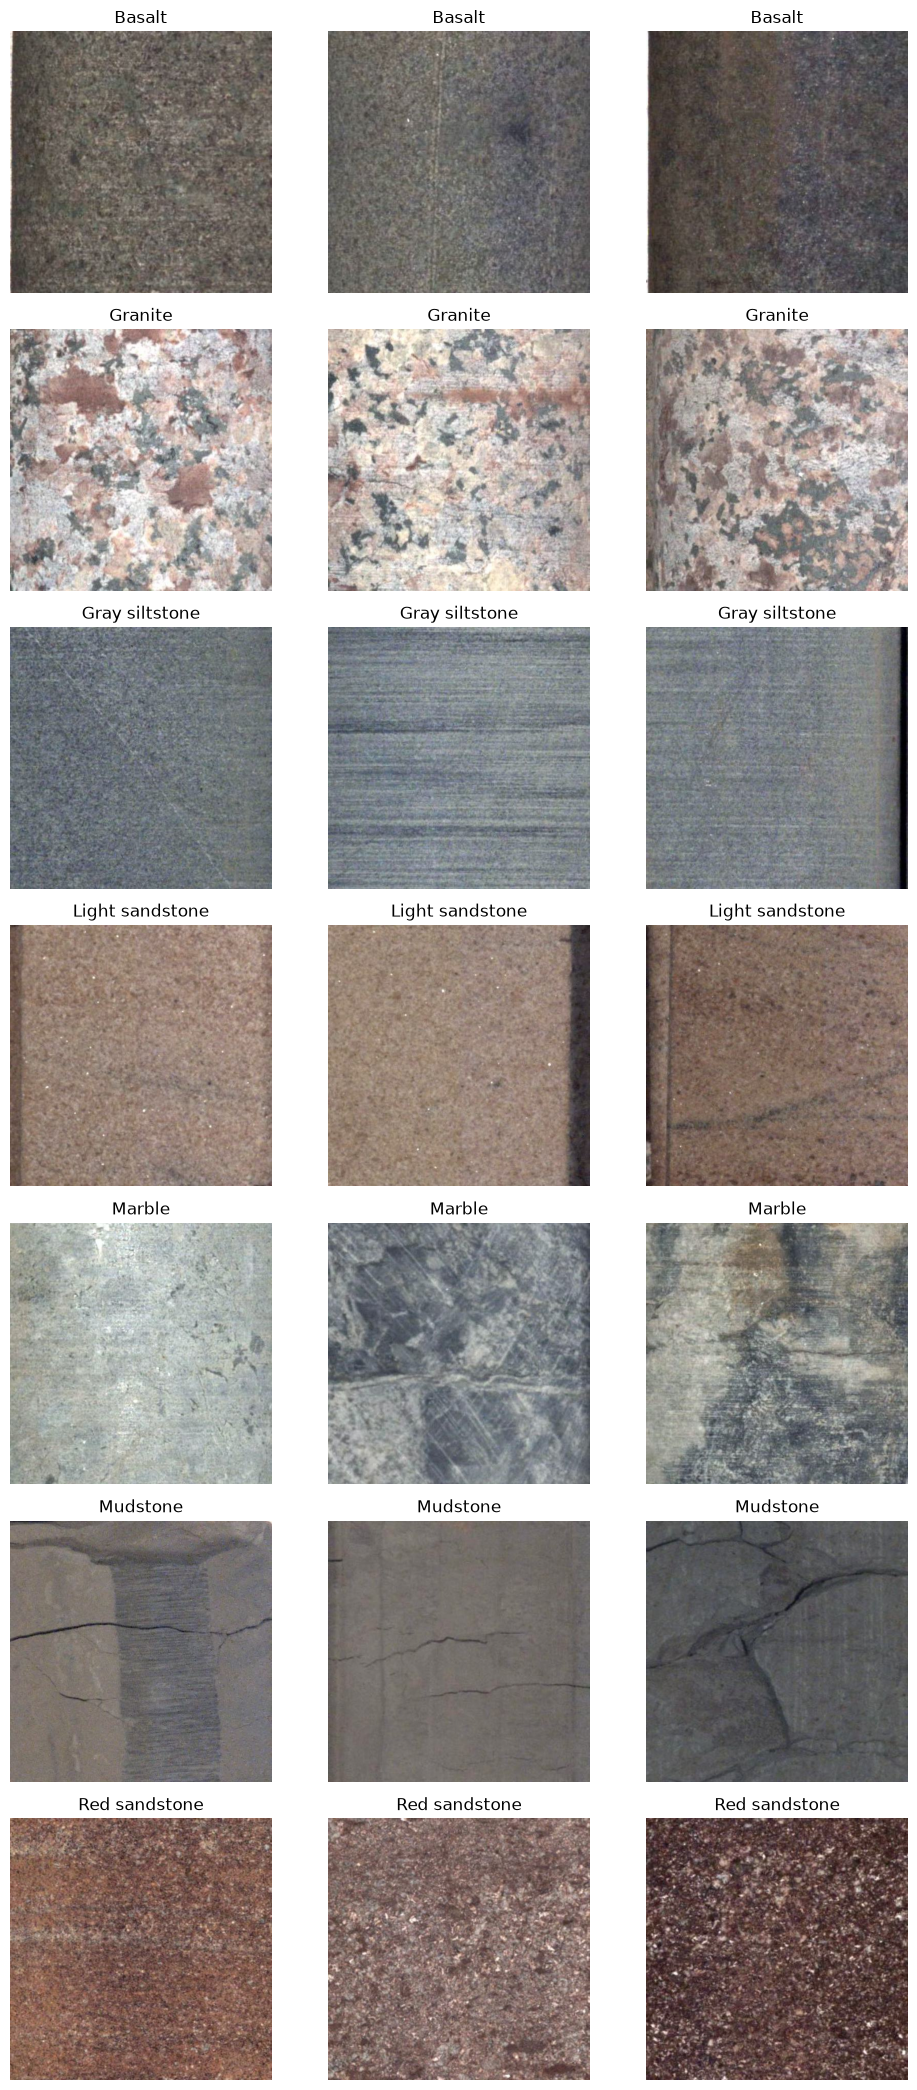

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(train_df["label"].unique())

fig, axes = plt.subplots(
    len(classes), 3,
    figsize=(10, 3 * len(classes))
)

for row, class_name in enumerate(classes):

    samples = train_df[
        train_df["label"] == class_name
    ].sample(3, random_state=SEED)

    for col, (_, record) in enumerate(samples.iterrows()):

        image = Image.open(record["image_path"]).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

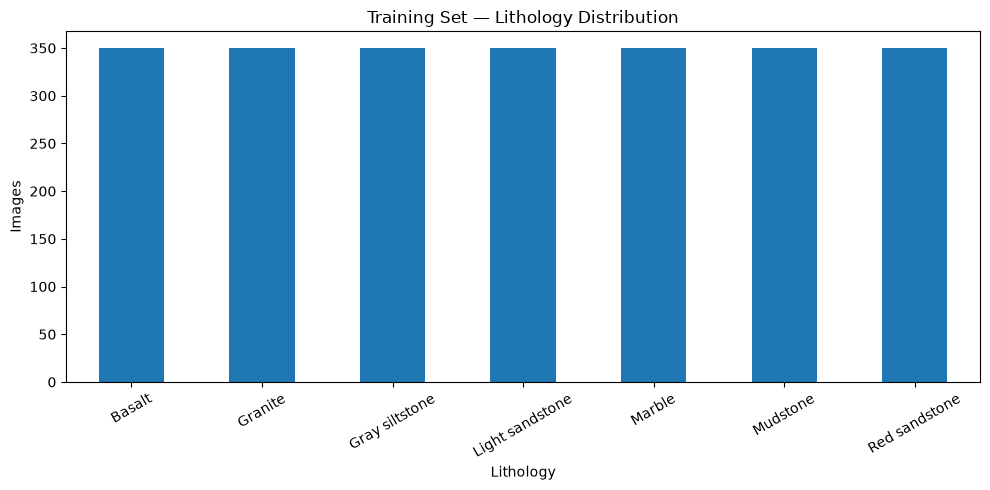

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

train_df["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Training Set — Lithology Distribution")
plt.xlabel("Lithology")
plt.ylabel("Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [20]:
from collections import Counter
from PIL import Image

dimensions = Counter()

for path in train_df["image_path"]:
    with Image.open(path) as image:
        dimensions[image.size] += 1

print("Image dimensions in training set:\n")

for dimension, count in dimensions.most_common():
    print(f"{dimension}: {count}")

Image dimensions in training set:

(512, 512): 2450


In [21]:
bad_images = []

for dataframe_name, dataframe in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    
    for path in dataframe["image_path"]:
        try:
            with Image.open(path) as image:
                image.verify()
        except Exception as e:
            bad_images.append({
                "split": dataframe_name,
                "path": path,
                "error": str(e)
            })

print("Total images checked:",
      len(train_df) + len(val_df) + len(test_df))

print("Bad images:", len(bad_images))

if bad_images:
    display(pd.DataFrame(bad_images).head(20))

Total images checked: 5250
Bad images: 0


In [22]:
print("Duplicate paths:")

for name, dataframe in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    print(
        name,
        "→",
        dataframe["image_path"].duplicated().sum()
    )

Duplicate paths:
train → 0
validation → 0
test → 0


In [23]:
train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test:", len(train_paths & test_paths))
print("Validation ∩ Test:", len(val_paths & test_paths))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [24]:
from pathlib import Path

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(
    PROCESSED_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    PROCESSED_DIR / "validation.csv",
    index=False
)

test_df.to_csv(
    PROCESSED_DIR / "test.csv",
    index=False
)

print("Saved:")
print(PROCESSED_DIR / "train.csv")
print(PROCESSED_DIR / "validation.csv")
print(PROCESSED_DIR / "test.csv")

Saved:
C:\Documents\GeoSigLIP\data\processed\train.csv
C:\Documents\GeoSigLIP\data\processed\validation.csv
C:\Documents\GeoSigLIP\data\processed\test.csv


In [25]:
print("=" * 60)
print("GEOSIGLIP — DCID-7 DATASET")
print("=" * 60)

print(f"\nTotal selected: {len(train_df) + len(val_df) + len(test_df)}")

print("\nSplits:")
print(f"Train:       {len(train_df)}")
print(f"Validation:  {len(val_df)}")
print(f"Test:        {len(test_df)}")

print("\nClasses:")
for i, label in enumerate(sorted(train_df["label"].unique()), 1):
    print(f"{i}. {label}")

print("\nImages per training class:")
print(train_df["label"].value_counts().sort_index())

print("\nImages per validation class:")
print(val_df["label"].value_counts().sort_index())

print("\nImages per test class:")
print(test_df["label"].value_counts().sort_index())

print("\nBad images:", len(bad_images))

print("\nSaved manifests to:")
print(PROCESSED_DIR)

GEOSIGLIP — DCID-7 DATASET

Total selected: 5250

Splits:
Train:       2450
Validation:  1050
Test:        1750

Classes:
1. Basalt
2. Granite
3. Gray siltstone
4. Light sandstone
5. Marble
6. Mudstone
7. Red sandstone

Images per training class:
label
Basalt             350
Granite            350
Gray siltstone     350
Light sandstone    350
Marble             350
Mudstone           350
Red sandstone      350
Name: count, dtype: int64

Images per validation class:
label
Basalt             150
Granite            150
Gray siltstone     150
Light sandstone    150
Marble             150
Mudstone           150
Red sandstone      150
Name: count, dtype: int64

Images per test class:
label
Basalt             250
Granite            250
Gray siltstone     250
Light sandstone    250
Marble             250
Mudstone           250
Red sandstone      250
Name: count, dtype: int64

Bad images: 0

Saved manifests to:
C:\Documents\GeoSigLIP\data\processed


In [26]:
# Save portable manifests for Kaggle

portable_train = train_df.copy()
portable_val = val_df.copy()
portable_test = test_df.copy()

for df in [portable_train, portable_val, portable_test]:
    df["image_path"] = df["image_path"].apply(
        lambda x: str(Path(x).relative_to(PROJECT_ROOT))
    )

portable_train.to_csv(
    PROCESSED_DIR / "train.csv",
    index=False
)

portable_val.to_csv(
    PROCESSED_DIR / "validation.csv",
    index=False
)

portable_test.to_csv(
    PROCESSED_DIR / "test.csv",
    index=False
)

print("Portable manifests saved.")
print(portable_train.head())

Portable manifests saved.
                                             image_path           label
2014  data\raw\DCID\DCID-512-7\train\5.Granite\5.Gra...         Granite
102   data\raw\DCID\DCID-512-7\train\1.Red sandstone...   Red sandstone
1408  data\raw\DCID\DCID-512-7\train\3.Gray siltston...  Gray siltstone
340   data\raw\DCID\DCID-512-7\train\1.Red sandstone...   Red sandstone
1502  data\raw\DCID\DCID-512-7\train\4.Mudstone\4.Mu...        Mudstone
